In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ema_workbench.analysis import pairs_plotting
from ema_workbench.analysis import feature_scoring
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
from sklearn import tree
from pprint import pprint 
import graphviz
import sklearn
import dtreeviz

import os
import sys
sys.path.insert(0, '..')

from archspace import GatewayAggregation, ArchSpace
from archspace import show_pairplot, show_feature_scores, show_outcome_distributions, show_tradeoff_distribution
from archspace import show_quality_attribute_space2D, show_configuration_space2D

In [2]:
# from os import listdir
# from os.path import isfile, join

# mypath = "./additional-results"
# onlyfiles = [f for f in listdir(mypath) if isfile(join(mypath, f))]

# list_dfs = []
# for f in onlyfiles:
#     df = pd.read_csv(mypath + "/" + f)
#     print(f, df.shape)
#     list_dfs.append(df) 
# df = pd.concat(list_dfs, axis=0, ignore_index=True)
# df.to_csv("./multi_N25_Sgw.csv", index=False)
# df

In [3]:
my_space = GatewayAggregation()
my_space.create_model('gateway aggregation')

# experiments_df, outcomes_df = my_space.load_results('./multi_N25.csv')
experiments_df, outcomes_df = my_space.load_results('./multi_N25_Sgw.csv')

print(len(my_space.get_configurations()), "configurations")
print(experiments_df.isnull().values.any())
print(outcomes_df.isnull().values.any())

(78, 43)
1 configurations
False
False


In [4]:
experiments_df

,scenario,N_A,N_B,r_Z_A,r_Z_B,r_A_gw,r_B_gw,r_A_s1,r_B_s1,r_A_s2,r_B_s2,r_A_s3,r_B_s3,model,policy
0,0,0,25,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
1,1,0,25,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
2,2,0,25,0.01,0.01,0.200000,0.200000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
3,3,1,24,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
4,4,1,24,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,73,24,1,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
74,74,24,1,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
75,75,25,0,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
76,76,25,0,0.01,0.01,0.200000,0.200000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0


In [5]:
experiments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   scenario  78 non-null     int64   
 1   N_A       78 non-null     int64   
 2   N_B       78 non-null     int64   
 3   r_Z_A     78 non-null     float64 
 4   r_Z_B     78 non-null     float64 
 5   r_A_gw    78 non-null     float64 
 6   r_B_gw    78 non-null     float64 
 7   r_A_s1    78 non-null     float64 
 8   r_B_s1    78 non-null     float64 
 9   r_A_s2    78 non-null     float64 
 10  r_B_s2    78 non-null     float64 
 11  r_A_s3    78 non-null     float64 
 12  r_B_s3    78 non-null     float64 
 13  model     78 non-null     object  
 14  policy    78 non-null     category
dtypes: category(1), float64(10), int64(3), object(1)
memory usage: 8.8+ KB


/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
OMP: Info #270: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


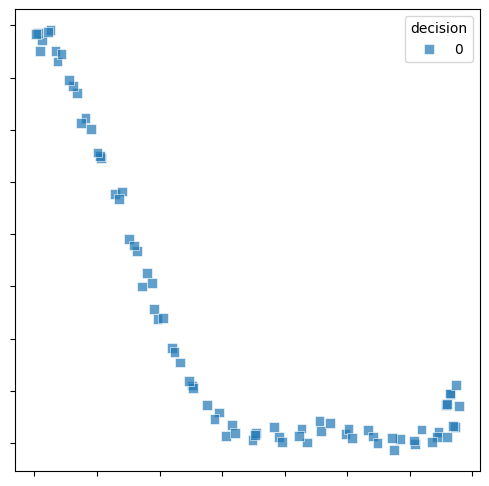

In [6]:
embeddings_df = show_configuration_space2D(experiments_df, alpha=0.7)

In [7]:
outcomes_df

,response_time,utilization
0,506.783442,0.982808
1,449.726103,0.843158
2,450.920676,0.273558
3,506.892230,0.989886
4,437.319142,0.847359
...,...,...
73,475.413050,0.790515
74,516.119104,0.966193
75,501.975245,0.747687
76,504.789121,0.250878


In [8]:
outcomes_df.describe()

,response_time,utilization
count,78.000000,78.000000
mean,432.326533,0.746486
std,60.971140,0.300598
min,337.806559,0.250878
25%,386.739739,0.363758
50%,420.453393,0.943982
75%,499.058949,0.990208
max,529.222573,0.999945


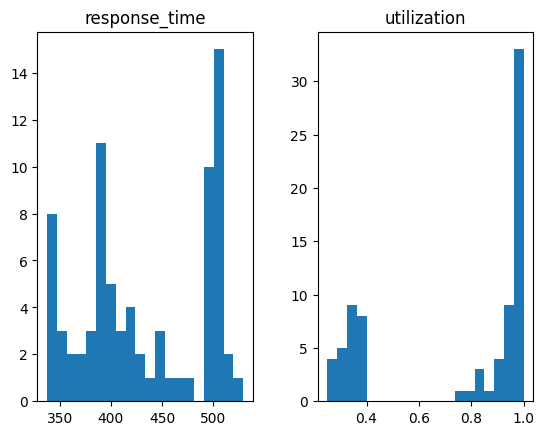

In [9]:
# outcomes
outcomes_df.hist(bins=20, grid=False)
plt.show()

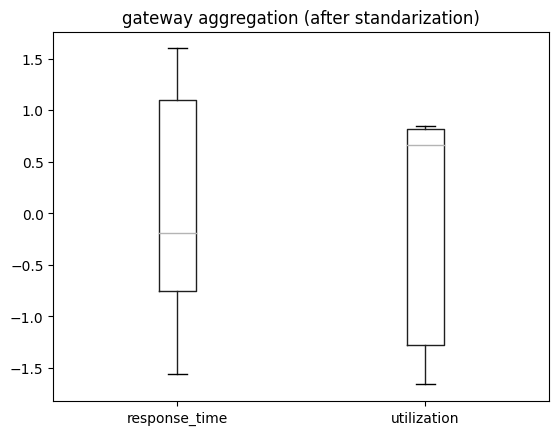

In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outcomes_df)
scaled_df = pd.DataFrame(scaled_data, columns=outcomes_df.columns)
scaled_df.boxplot(grid=False)
plt.title('gateway aggregation (after standarization)')
plt.show()

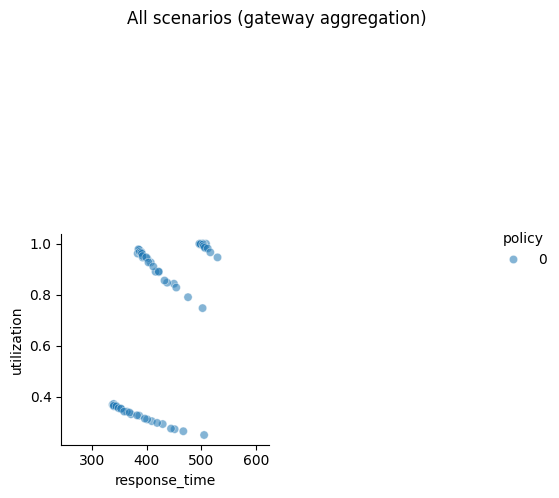

In [11]:
# show_pairplot(experiments_df, outcomes, title='All scenarios (gateway aggregation)', kind='sns')
show_pairplot(my_space, title='All scenarios (gateway aggregation)', kind='sns', group='policy', legend=True) #, filename=None)

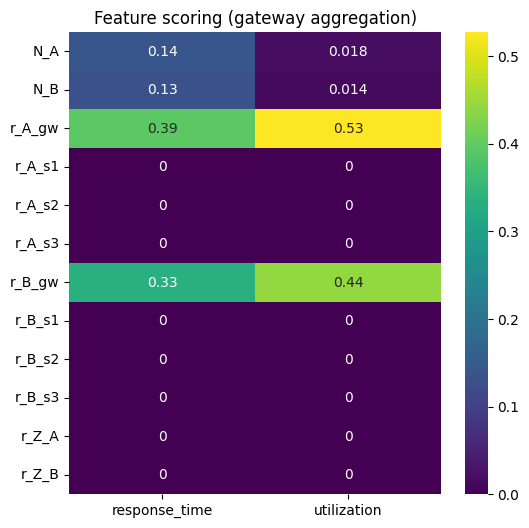

,response_time,utilization
0,,
N_A,0.140205,0.017533
N_B,0.131158,0.014289
r_A_gw,0.394339,0.527315
r_A_s1,0.000000,0.000000
r_A_s2,0.000000,0.000000
r_A_s3,0.000000,0.000000
r_B_gw,0.334299,0.440863
r_B_s1,0.000000,0.000000
r_B_s2,0.000000,0.000000


In [12]:
fs = show_feature_scores(my_space, title='Feature scoring (gateway aggregation)') #, filename=None)   
fs

Absolute ranges: [(330.0, 530.0), (0.0, 1.0)]
response_time [329.9, 396.6333333333333, 463.3666666666667, 530.1]
utilization [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]


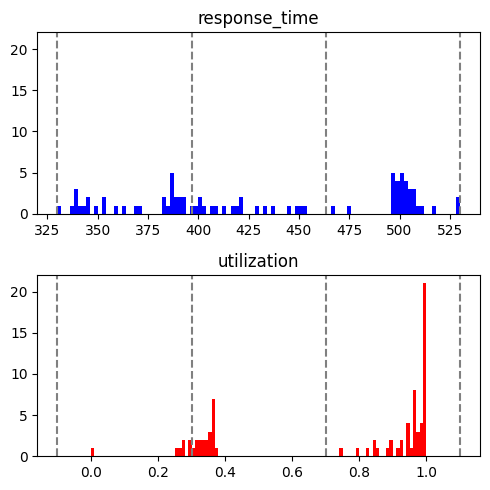

{'response_time': [329.9, 396.6333333333333, 463.3666666666667, 530.1],
 'utilization': [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]}

In [13]:
MIN_RESPONSE_TIME, MAX_RESPONSE_TIME = (330.0, 530.0)
MIN_UTILIZATION, MAX_UTILIZATION = (0.0, 1.0)
MIN_MAX_RANGES = [(MIN_RESPONSE_TIME, MAX_RESPONSE_TIME), (MIN_UTILIZATION, MAX_UTILIZATION)]
print('Absolute ranges:', MIN_MAX_RANGES)

show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5))

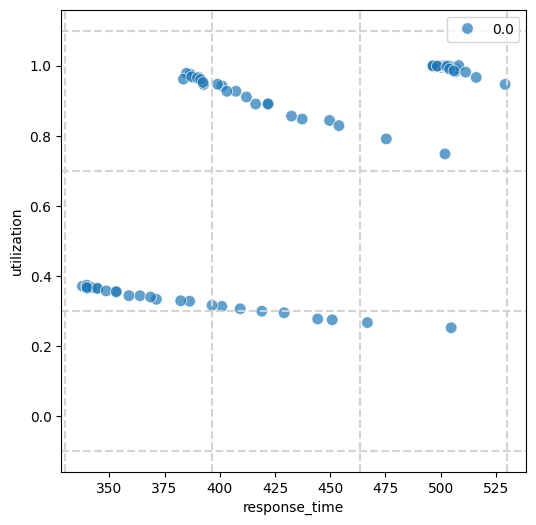

In [14]:
df = outcomes_df.copy()
df['decision'] = experiments_df['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7)

In [15]:
print("Configurations:", my_space.get_configurations())

Configurations: [0]


In [16]:
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", experiments_df.shape)

config = 0
exp_df, out_df, discrete_out_df = my_space.get_experiment(config)

# print(exp_df.head())
# print(out_df.head())
# print(discrete_exp_df)
# print(my_space.available_tradeoffs_)
print("Tradeoffs for ", config,"-->", GatewayAggregation.get_tradeoffs(discrete_out_df))
discrete_out_df.head(10)

Experiments: (78, 15)
Tradeoffs for  0 --> Counter({'slow,high': 28, 'fast,average': 18, 'average,high': 12, 'fast,high': 12, 'average,low': 4, 'average,average': 2, 'slow,low': 2})


,response_time,utilization
0,slow,high
1,average,high
2,average,low
3,slow,high
4,average,high
5,average,low
6,average,average
7,slow,high
8,average,high
9,average,high


In [17]:
my_space.available_tradeoffs_

Counter({'slow,high': 28,
         'fast,average': 18,
         'average,high': 12,
         'fast,high': 12,
         'average,low': 4,
         'average,average': 2,
         'slow,low': 2})

In [18]:
X_train, X_test, y_train, y_test = my_space.split_dataset(test_size=0.2)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(78, 17) 78
Instances to remove (not enough tradeoffs): set()
{'slow,high', 'average,average', 'average,low', 'slow,low', 'fast,high', 'average,high', 'fast,average'}
(78, 17) 78
(62, 17) (62, 2) (16, 17) (16, 2)


In [19]:
X_train

,scenario,N_A,N_B,r_Z_A,r_Z_B,r_A_gw,r_B_gw,r_A_s1,r_B_s1,r_A_s2,r_B_s2,r_A_s3,r_B_s3,model,policy,response_time,utilization
0,0,0,25,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0,506.783442,0.982808
1,59,19,6,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0,498.474915,0.998374
2,2,0,25,0.01,0.01,0.200000,0.200000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0,450.920676,0.273558
3,24,8,17,0.01,0.01,0.200000,0.200000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0,344.148460,0.364156
4,36,12,13,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0,499.039832,0.999925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,4,1,24,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0,437.319142,0.847359
58,30,10,15,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0,386.818330,0.974655
59,67,22,3,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0,506.041453,0.984852
60,13,4,21,0.01,0.01,0.200000,0.200000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0,386.346433,0.326628


In [20]:
my_space.import_dataset(X_train, y_train)

In [21]:
# reference_tradeoff = None #'slow,average'
# reference_tradeoff = ['average,average', 'average,high']
# r1, qat = my_space.compute_robustness([config], reference_tradeoff)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# print()

# list_of_configs = my_space.get_nearest_configurations(config, k=1)
# # list_of_configs = configs_df.values.tolist()
# # print(all(isinstance(elem, list) for elem in list_of_configs), list_of_configs)
# r1, qat = my_space.compute_robustness(list_of_configs, reference_tradeoff) 
# print("Robustness of list of solutions", list_of_configs, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# # print(configs_df)
# print()
# qa_config = 'average,average'
# qa_configs = my_space.get_nearest_tradeoffs(qa_config, k=1)
# print("Neighbors of:", qa_configs)
# print()
# qat = my_space.get_nearest_tradeoffs(qa_config, k=2)
# r1, qat = my_space.compute_robustness([config], qa_config)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# r1, qat = my_space.compute_robustness([config], qa_configs[0:2])
# print("Robustness of single solution", config, "w.r.t list of tradeoffs:", qat, "-->", round(r1*100, 2), "%")
# print()

Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 20.78it/s]


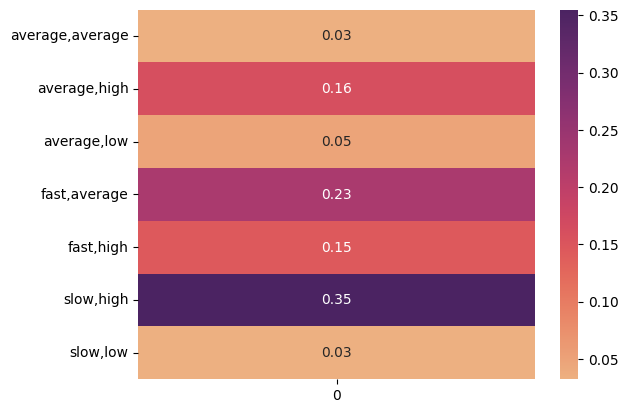

,0
"average,average",0.032258
"average,high",0.161290
"average,low",0.048387
"fast,average",0.225806
"fast,high",0.145161
"slow,high",0.354839
"slow,low",0.032258


In [22]:
print("Computing robustness for all configurations...")
df = my_space.compute_robustness_matrix()
# df.to_csv('./gateway_aggregation_robustness_matrix.csv')

sns.heatmap(df, annot=True, fmt=".2f", cmap='flare')
plt.show()
df

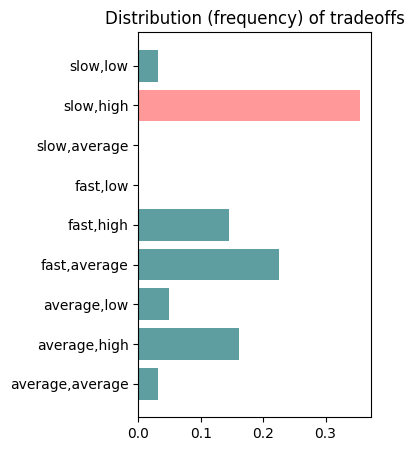

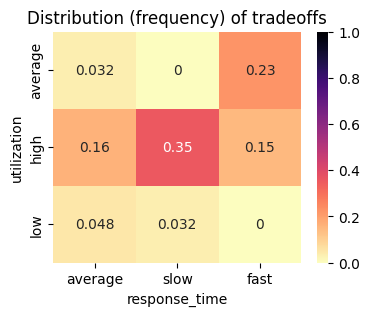

In [23]:
show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

0 Counter({'slow,high': 22, 'fast,average': 14, 'average,high': 10, 'fast,high': 9, 'average,low': 3, 'average,average': 2, 'slow,low': 2})
Instances for configuration: (62, 2)


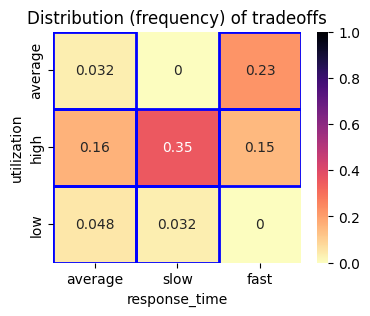

In [24]:
config = 0
# show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [25]:
config = 0
_, _, config_outcomes_df = my_space.get_experiment(config)
# config_outcomes_df

In [26]:
label_values_df = my_space.describe_labels(n_bins=3)
label_values_df

,objective,min,max,label
0,response_time,337.706559,401.578563,fast
1,response_time,401.578563,465.450568,average
2,response_time,465.450568,529.322573,slow
3,utilization,0.150878,0.467227,low
4,utilization,0.467227,0.783576,average
5,utilization,0.783576,1.099925,high


In [27]:
kp = ['N_A', 'N_B']
rules, cart_model = my_space.run_cart(key_parameters=kp, prune_tree=True)
clf = cart_model.clf
print("nodes:", clf.tree_.node_count, "leaves:", clf.get_n_leaves())

for r in rules:
    print(r)

(62, 2) Index(['N_A', 'N_B'], dtype='object')
Running CART ...
nodes: 29 leaves: 20
if N_B <= 19.5 and N_A > 17.5 then class: slow,high (proba: 45.0%) | based on 20 samples
if N_B > 19.5 and N_A <= 1.5 then class: slow,high (proba: 33.0%) | based on 6 samples
if N_B <= 19.5 and N_A <= 17.5 and N_A <= 8.5 then class: average,low (proba: 50.0%) | based on 6 samples
if N_B > 19.5 and N_A > 1.5 and N_A > 3.5 then class: slow,high (proba: 40.0%) | based on 5 samples
if N_B > 19.5 and N_A > 1.5 and N_A <= 3.5 then class: fast,average (proba: 40.0%) | based on 5 samples
if N_B <= 19.5 and N_A <= 17.5 and N_A > 8.5 and N_B > 9.5 and N_A <= 10.5 then class: slow,high (proba: 40.0%) | based on 5 samples
if N_B <= 19.5 and N_A <= 17.5 and N_A > 8.5 and N_B > 9.5 and N_A > 10.5 and N_B <= 11.5 then class: slow,high (proba: 50.0%) | based on 4 samples
if N_B <= 19.5 and N_A <= 17.5 and N_A > 8.5 and N_B > 9.5 and N_A > 10.5 and N_B > 11.5 and N_B <= 13.5 then class: average,low (proba: 50.0%) | bas

|--- feature_1 <= 19.50
|   |--- feature_0 <= 17.50
|   |   |--- feature_0 <= 8.50
|   |   |   |--- class: 2
|   |   |--- feature_0 >  8.50
|   |   |   |--- feature_1 <= 9.50
|   |   |   |   |--- class: 4
|   |   |   |--- feature_1 >  9.50
|   |   |   |   |--- feature_0 <= 10.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_0 >  10.50
|   |   |   |   |   |--- feature_1 <= 11.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- feature_1 >  11.50
|   |   |   |   |   |   |--- feature_1 <= 13.50
|   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |   |--- feature_1 >  13.50
|   |   |   |   |   |   |   |--- class: 0
|   |--- feature_0 >  17.50
|   |   |--- class: 0
|--- feature_1 >  19.50
|   |--- feature_0 <= 1.50
|   |   |--- class: 0
|   |--- feature_0 >  1.50
|   |   |--- feature_0 <= 3.50
|   |   |   |--- class: 3
|   |   |--- feature_0 >  3.50
|   |   |   |--- class: 0



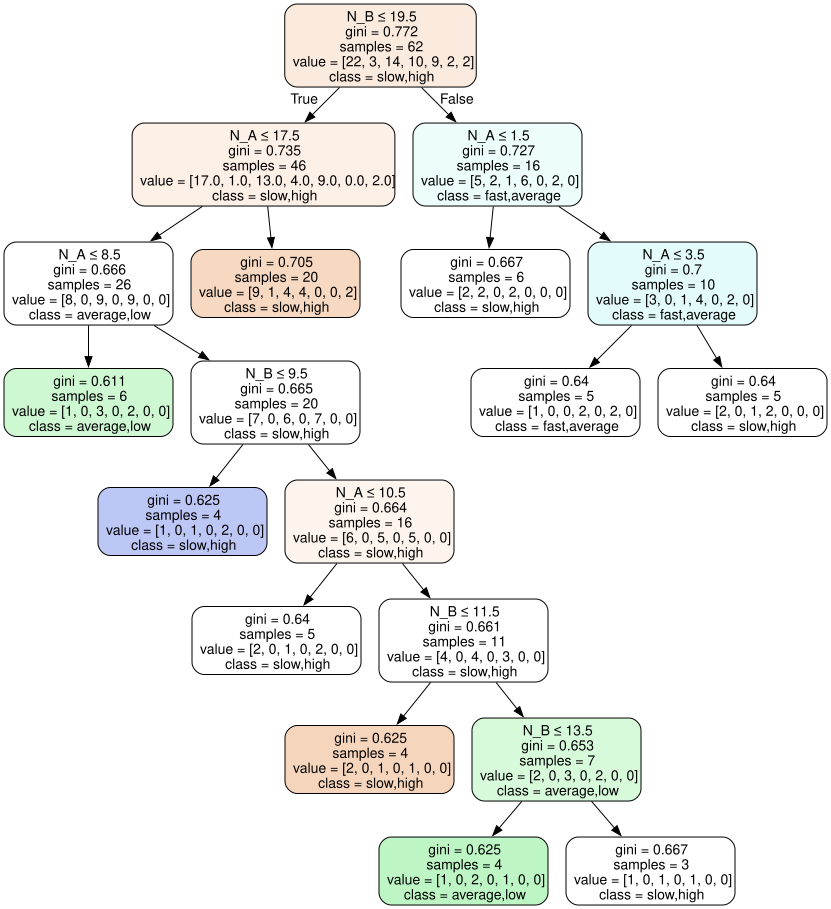

In [28]:
class_names =  my_space._get_cluster_labels()
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=kp, class_names=class_names,
                                filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)

print(tree.export_text(cart_model.clf))
# pprint(tree.export_text(prunedTree))

graph

In [27]:
# my_space.import_dataset(X_test, y_test)
my_space.import_dataset(X_train, y_train)
print("  Computing robustness for all configurations...")
print(my_space.available_tradeoffs_)

df = my_space.compute_robustness_matrix()
df

  Computing robustness for all configurations...
Counter({'slow,high': 22, 'fast,average': 14, 'average,high': 10, 'fast,high': 9, 'average,low': 3, 'average,average': 2, 'slow,low': 2})


100%|██████████| 1/1 [00:00<00:00, 12.26it/s]

0


,0
"average,average",0.032258
"average,high",0.161290
"average,low",0.048387
"fast,average",0.225806
"fast,high",0.145161
"slow,high",0.354839
"slow,low",0.032258


In [28]:
warnings.filterwarnings('ignore')
my_space.import_dataset(X_train, y_train)

kp = ['N_A', 'N_B']

for qa_label in my_space.available_tradeoffs_.keys():
    my_space.import_dataset(X_train, y_train)
    n = my_space.available_tradeoffs_[qa_label]
    
    if n > 0:
        print("Checking (with PRIM) ----")
        property_to_check = my_space.get_property_box(qa_label)
        print("  ", qa_label, property_to_check)
        
        box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp, verbose=False)
        print("  New ranges:",  prange)

        my_space.import_dataset(X_test, y_test)
        my_space.adjust_parameters(prange)
        _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
        print("  Experiments:", my_space.experiments_df_.shape)

        print("  Computing robustness for all configurations...")
        df = my_space.compute_robustness_matrix()
        print(df)
        # plt.show()

Checking (with PRIM) ----
   slow,high {'response_time': (463.3666666666667, 530.1), 'utilization': (0.7000000000000002, 1.1)}
  New ranges: {'N_A': {'min': 9.0, 'max': 25.0}, 'N_B': {'min': 0.0, 'max': 17.0}}
  Experiments: (11, 15)
  Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 13.79it/s]


0
                     0
average,high  0.181818
average,low   0.090909
fast,average  0.272727
fast,high     0.181818
slow,high     0.272727
Checking (with PRIM) ----
   average,low {'response_time': (396.6333333333333, 463.3666666666667), 'utilization': (-0.1, 0.30000000000000004)}
  New ranges: {'N_A': {'min': 0.0, 'max': 23.0}, 'N_B': {'min': 3.0, 'max': 25.0}}
  Experiments: (14, 15)
  Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 42.51it/s]

0


...

100%|██████████| 1/1 [00:00<00:00, 138.54it/s]

0
             0
slow,high  1.0
Checking (with PRIM) ----
   slow,low {'response_time': (463.3666666666667, 530.1), 'utilization': (-0.1, 0.30000000000000004)}


  New ranges: {'N_B': {'min': 0.0, 'max': 1.0}}
  Experiments: (1, 15)
  Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 150.69it/s]

0
             0
slow,high  1.0


In [29]:
my_space.import_dataset(X_train, y_train)

# GatewayAggregation.get_property_box('average,high', label_values_df)
qa_label = 'average,high'
property_to_check = my_space.get_property_box(qa_label)
print(qa_label, property_to_check)

average,high {'response_time': (396.6333333333333, 463.3666666666667), 'utilization': (0.7000000000000002, 1.1)}


In [30]:
# my_space.experiments_df_.columns

In [31]:
# kp = ['N_A', 'N_B']
# box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='emaw', key_parameters=kp)
box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp)
prange

Instances satisfying property: False    52
True     10
Name: count, dtype: int64
Total instances: (62, 2)
Running PRIM ... rhodium
2 boxes


{'N_A': {'min': 0.0, 'max': 23.0}}

In [32]:
# EMAWorkbench
# fig = plt.figure(figsize=(24,12))
# box1.show_tradeoff(annotated=True)
# box1.show_pairs_scatter(upper='none', lower='scatter')
# box1.inspect(style='graph')

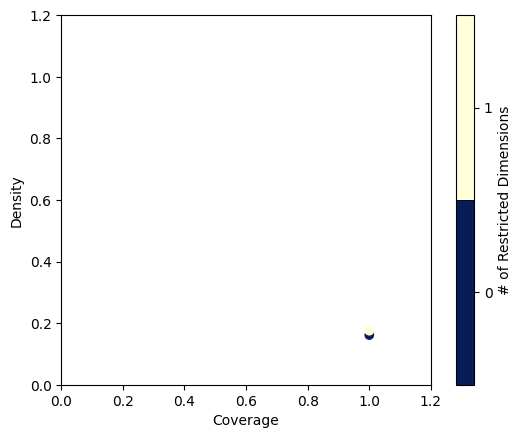

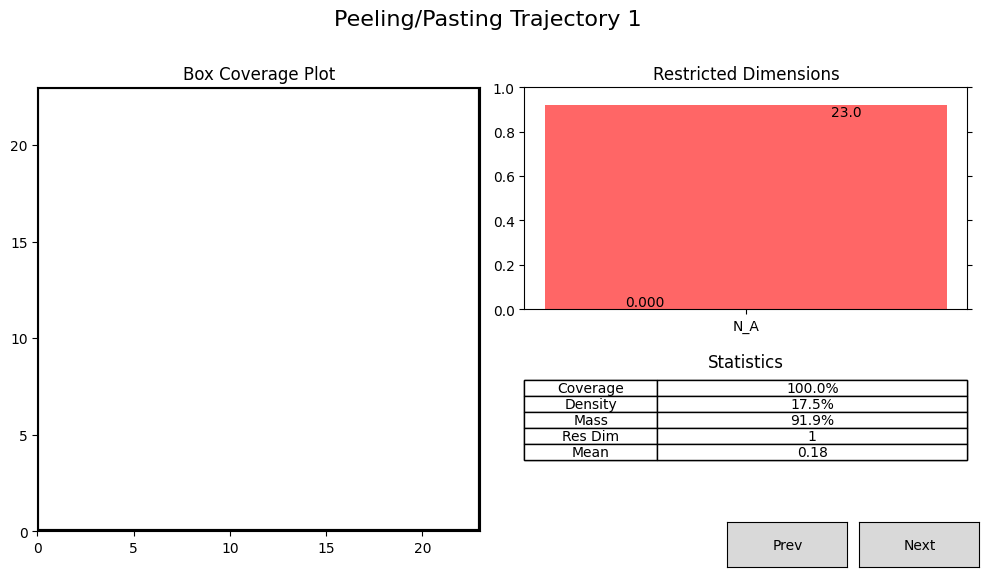

In [33]:
# Rhodium
# fig = plt.figure(figsize=(24,12))
box1.show_tradeoff()
box1.show_details()
plt.show()

Instances satisfying property: False    52
True     10
Name: count, dtype: int64
Total instances: (62, 2)
Running PRIM ... rhodium
2 boxes


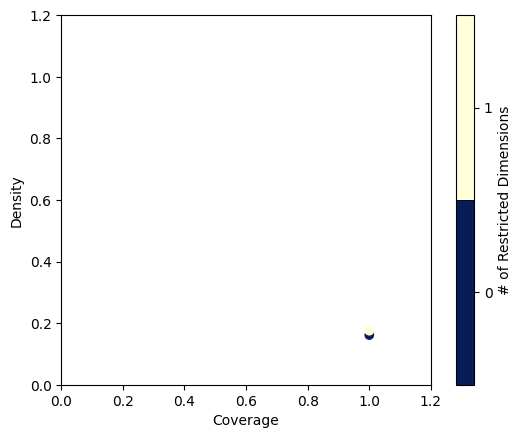

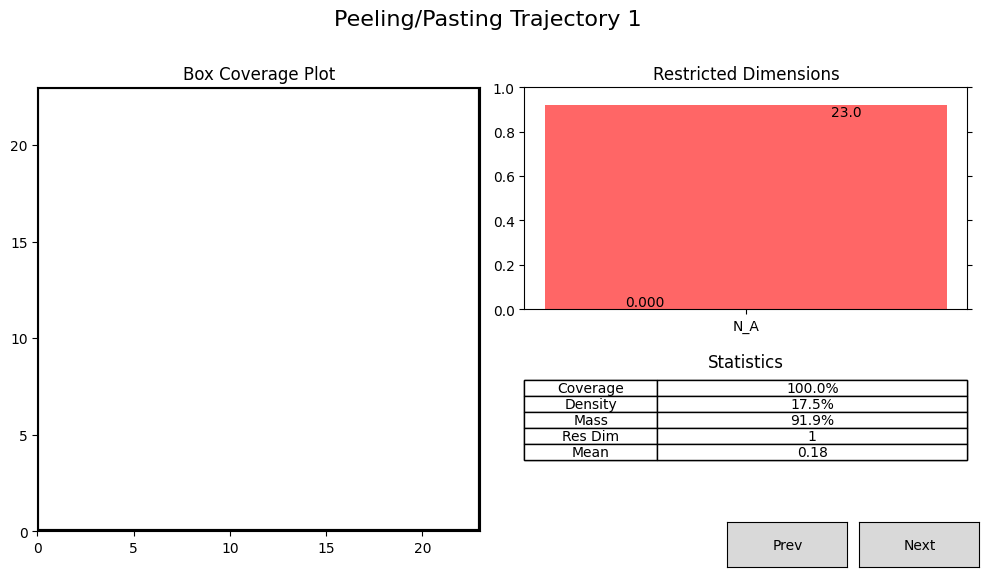

In [34]:
# For Rhodium only
boxes = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp, n_boxes=True)
for b in boxes:
    # print(ArchSpace.get_limits(b).shape)
    box_shape = ArchSpace.get_box_limits(b).shape[0]
    if box_shape > 0:
        b.show_tradeoff()
        b.show_details()
        plt.show()
        # box1 = b

In [35]:
ArchSpace.get_box_limits(box1)[['min', 'max']].to_dict(orient='index')

{'N_A': {'min': 0.0, 'max': 23.0}}

In [36]:
# my_space.experiments_df_.describe()

In [37]:
my_space.import_dataset(X_test, y_test)

In [38]:
my_space.experiments_df_

,scenario,N_A,N_B,r_Z_A,r_Z_B,r_A_gw,r_B_gw,r_A_s1,r_B_s1,r_A_s2,r_B_s2,r_A_s3,r_B_s3,model,policy
0,74,24,1,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
1,68,22,3,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
2,29,9,16,0.01,0.01,0.200000,0.200000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
3,38,12,13,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
4,41,13,12,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
5,10,3,22,0.01,0.01,0.050000,0.050000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
6,47,15,10,0.01,0.01,0.200000,0.200000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
7,26,8,17,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
8,17,5,20,0.01,0.01,0.200000,0.200000,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0
9,45,15,10,0.01,0.01,0.066667,0.066667,0.142857,0.055556,0.066667,0.083333,0.05,0.2,gateway_aggregation,0


Reducing range for tradeoff: average,high {'response_time': (396.6333333333333, 463.3666666666667), 'utilization': (0.7000000000000002, 1.1)}
New ranges: {'N_A': {'min': 0.0, 'max': 23.0}}
Experiments: (15, 15)


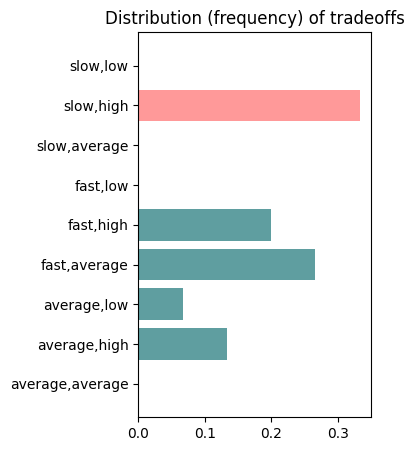

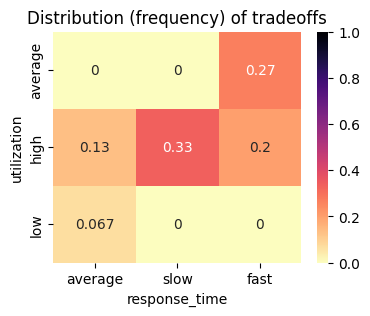

In [39]:
print("Reducing range for tradeoff:", qa_label, property_to_check)
print("New ranges:",  prange)

my_space.adjust_parameters(prange)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

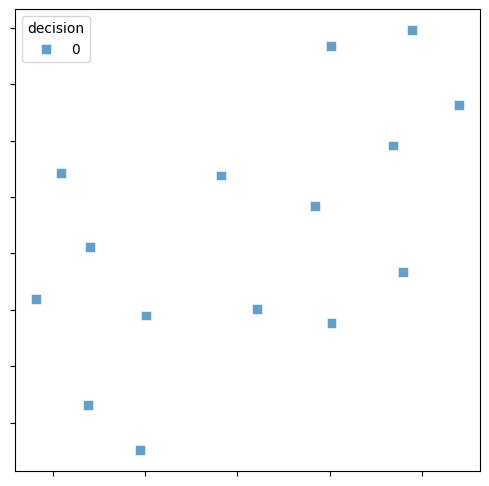

In [40]:
embeddings_df = show_configuration_space2D(my_space.experiments_df_, alpha=0.7)

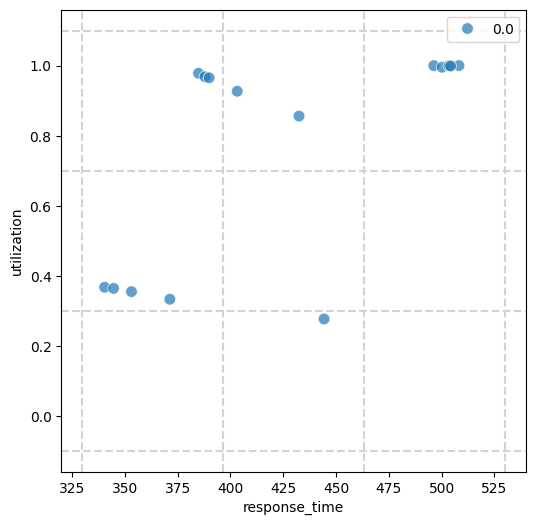

In [41]:
df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7)

In [42]:
print("Computing robustness for all configurations...")
main_dict = dict()
for exp in tqdm(my_space.get_configurations()):
    print(exp)
    main_dict[str(exp)] = dict()
    for qa in my_space.available_tradeoffs_.keys():
        main_dict[str(exp)][qa], _ = my_space.compute_robustness(exp, qa)
df = pd.DataFrame.from_dict(main_dict, orient='columns').sort_index()
df

Computing robustness for all configurations...


100%|██████████| 1/1 [00:00<00:00, 27.98it/s]

0


,0
"average,high",0.133333
"average,low",0.066667
"fast,average",0.266667
"fast,high",0.200000
"slow,high",0.333333
